In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
main = Path.cwd()
resultsDir = main / "results"

result = resultsDir / "msk_impact_50k_2026_HOTAIR_mf100_ni20.csv"

# Use Path throughout and verify it resolves correctly
mskDir = Path("./results/msk_impact_50k_2026")  # adjust if your notebook lives elsewhere
print(f"Looking in: {mskDir.resolve()}")
print(f"Exists: {mskDir.exists()}")

found = sorted(mskDir.glob("*.csv"))
print(f"CSVs found: {len(found)}")
for f in found:
    print(" ", f.name)

Looking in: /net/dali/home/mscbio/rop174/02604/lncRNA-DNAtriplex/results/msk_impact_50k_2026
Exists: True
CSVs found: 48
  msk_impact_50k_2026_CASC15_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_CCAT2_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_CCAT2_mf100_ni15_S1point0.csv
  msk_impact_50k_2026_CCAT2_mf100_ni20_S0point4.csv
  msk_impact_50k_2026_CCAT2_mf100_ni20_S1point0.csv
  msk_impact_50k_2026_CDKN2B_AS1_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_FENDRR_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_FENDRR_mf100_ni15_S1point0.csv
  msk_impact_50k_2026_FENDRR_mf100_ni20_S0point4.csv
  msk_impact_50k_2026_FENDRR_mf100_ni20_S1point0.csv
  msk_impact_50k_2026_GAS5_4_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4.csv
  msk_impact_50k_2026_HOTAIR_mf100_ni15_S1point0.csv
  msk_impact_50k_2026_HOTAIR_mf100_ni20_S0point4.csv
  msk_impact_50k_2026_HOTAIR_mf100_ni20_S1point0.csv
  msk_impact_50k_2026_HOXD_AS2_m

In [ ]:
df = pd.read_csv(result)
pd.set_option('display.max_columns', None)
df.head(100)

In [ ]:
# All columns after 'strand' are numeric — find that index
strand_idx = df.columns.get_loc("strand")
numeric_cols = df.columns[strand_idx + 1:]

# Keep rows where ANY of those columns is non-zero
mask = (df[numeric_cols] != 0).any(axis=1)
result = df[mask]

print(f"Total rows:    {len(df)}")
print(f"Non-zero rows: {len(result)}")
print(f"Filtered out:  {len(df) - len(result)}")

In [ ]:
pd.set_option('display.max_columns', None)
result.head(50)

In [ ]:
output_path = results / "msk_impact_50k_2026" / "filtered_msk_impact_50k_2026_HOTAIR_mf100_ni20.csv"

df.to_csv(output_path, index + False)

In [ ]:
mutations = main / "data" / "msk_impact_50k_2026" / "data_mutations.txt"

pd.set_option('display.max_columns', None)
df = pd.read_csv(mutations, sep = "\t")
df = df.dropna(axis=1, how='all') # remove all columns with just NaN
df.head(50)

In [ ]:
print(df['Consequence'].unique())

In [ ]:
print(df['Variant_Classification'].unique())

# Multiple Output Analysis

In [3]:
# mskDir = results / "msk_impact_50k_2026"
mskDir = Path("/net/dali/home/mscbio/rop174/02604/lncRNA-DNAtriplex/results/msk_impact_50k_2026")

frames = []
for path in sorted(mskDir.glob("*.csv")):
    df = pd.read_csv(path)
    
    parts = path.stem.split("_")  # .stem strips .csv cleanly
    df["source_file"]  = path.name
    ni_token           = next((p for p in parts if p.startswith("ni")), None)
    df["ni"] = int(ni_token[2:]) if ni_token else None
    S_token = next((p for p in parts if "point" in p), None)[1:]
    df["S"] = float(S_token.replace("point", "."))

    frames.append(df)

# Filter out rows without a difference in healthy vs mutated triplex formation
combined = pd.concat(frames, ignore_index=True)
result = combined[combined["delta_n_triplexes"] != 0].copy()

In [4]:
print(f"Combined shape before filter:     {combined.shape}")
print(f"Total rows:                       {len(combined)}")
print(f"Filtered out:                     {len(combined) - len(result)}")
print(f"Differences in Triplex formation: {len(result)}")
print()
print(result.groupby(["lnc_id", "ni", "S"]).size().rename("n_rows"))

Combined shape before filter:     (22996608, 31)
Total rows:                       22996608
Filtered out:                     22995887
Differences in Triplex formation: 721

lnc_id          ni  S  
DANCR:2         15  0.4      2
HOTAIR:3        15  0.4      2
                    1.0      2
                20  0.4      2
                    1.0      2
LINC-PINT:1     15  0.4      1
LINC-ROR:5      15  0.4      2
LINC01116:3     15  0.4      3
LINC01545:1     15  0.4      2
NEAT1:2         15  0.4      1
                20  0.4      1
PCED1B-AS1:1    15  0.4      3
PCGEM1:1        15  0.4      1
PWRN2:3         15  0.4      1
SAMMSON:1       15  0.4      2
ZEB2-AS1:3      15  0.4      1
                    1.0      1
                20  0.4      1
                    1.0      1
lnc-IFT122-1:1  15  0.4    685
lnc-SPHK1-1:1   15  0.4      5
Name: n_rows, dtype: int64


In [5]:
pd.set_option('display.max_columns', None)
result

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
3071426,DANCR:2,CTNNB1,P-0056450-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Splice_Site,DEL,NC_000003.11,41266072,41266253,41266062,41266262,+,0,0.0,0.0,0.0,0,0,1,61.2903,0.8065,2.7742,31,31,1,2.7742,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
3318287,DANCR:2,ELF3,P-0044320-T01-IM6,Bladder Cancer,Bladder Urothelial Carcinoma,BLCA,Splice_Site,DEL,NC_000001.10,201981382,201981563,201981372,201981572,+,0,0.0,0.0,0.0,0,0,1,72.0000,1.3200,3.2800,25,25,1,3.2800,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
5803365,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6226376,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6282461,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S1point0...,15,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22525669,lnc-SPHK1-1:1,ANKRD11,P-0061525-T01-IM7,Esophagogastric Cancer,Esophageal Adenocarcinoma,ESCA,Splice_Site,DEL,NC_000016.9,89357237,89357420,89357228,89357428,-,0,0.0,0.0,0.0,0,0,1,61.5385,1.2308,2.6923,26,26,1,2.6923,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22638164,lnc-SPHK1-1:1,PMS2,P-0052857-T05-IM7,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,LUAD,Splice_Site,DEL,NC_000007.13,6048521,6048702,6048511,6048711,-,0,0.0,0.0,0.0,0,0,1,61.2903,1.1935,2.5806,31,31,1,2.5806,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22657998,lnc-SPHK1-1:1,SPEN,P-0064385-T01-IM7,Colorectal Cancer,Rectal Adenocarcinoma,READ,In_Frame_Del,DEL,NC_000001.10,16262447,16262635,16262441,16262641,+,0,0.0,0.0,0.0,0,0,1,61.1111,1.1667,2.7222,18,18,1,2.7222,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22678101,lnc-SPHK1-1:1,NF1,P-0068323-T01-IM7,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000017.10,29556780,29556965,29556772,29556972,+,0,0.0,0.0,0.0,0,0,1,62.5000,0.6250,2.7083,24,24,1,2.7083,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4


# Evaluating ni/S sweep 

In [6]:
sweep = result[result['lnc_id'].isin(["HOTAIR:3", "NEAT1:2", "ZEB2-AS1:3"])]
sweep

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
5803365,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6226376,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6282461,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S1point0...,15,1.0
6705472,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni15_S1point0...,15,1.0
6761557,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni20_S0point4...,20,0.4
7184568,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni20_S0point4...,20,0.4
7240653,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni20_S1point0...,20,1.0
7663664,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni20_S1point0...,20,1.0
12496760,NEAT1:2,TP53,P-0019411-T01-IM6,Colorectal Cancer,Mucinous Adenocarcinoma of the Colon and Rectum,MACR,Splice_Site,DEL,NC_000017.10,7579191,7579367,7579179,7579379,-,0,0.0,0.0,0.0,0,0,1,62.1622,0.8649,2.7568,37,37,1,2.7568,msk_impact_50k_2026_NEAT1_mf100_ni15_S0point4.csv,15,0.4
13454952,NEAT1:2,TP53,P-0019411-T01-IM6,Colorectal Cancer,Mucinous Adenocarcinoma of the Colon and Rectum,MACR,Splice_Site,DEL,NC_000017.10,7579191,7579367,7579179,7579379,-,0,0.0,0.0,0.0,0,0,1,62.1622,0.8649,2.7568,37,37,1,2.7568,msk_impact_50k_2026_NEAT1_mf100_ni20_S0point4.csv,20,0.4


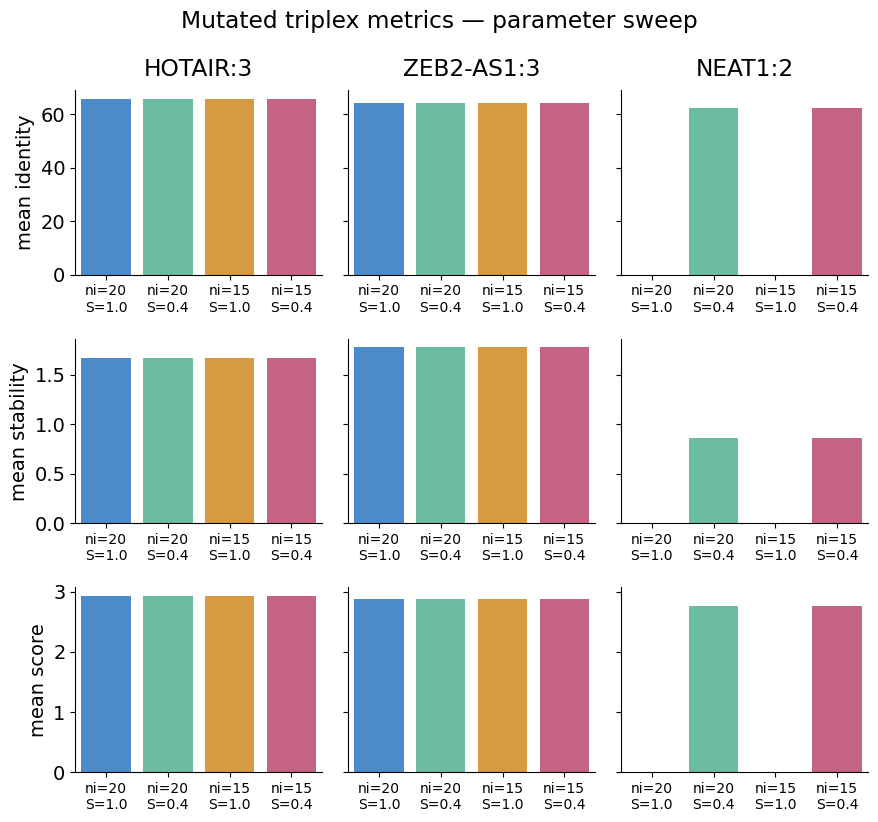

In [8]:
plt.rcParams["font.size"] = 14
plt.rcParams["figure.autolayout"] = True

# CHECKING SWEEP
METRICS = [
    "mutated_mean_identity",
    "mutated_mean_stability",
    "mutated_mean_score",
]
lncrnas = ["HOTAIR:3", "ZEB2-AS1:3", "NEAT1:2"]
PARAM_ORDER = [f"ni={ni}\nS={S}" for ni, S in [(20,1.0),(20,0.4),(15,1.0),(15,0.4)]]
PALETTE = dict(zip(PARAM_ORDER, ["#378ADD","#5DCAA5","#EF9F27","#D4537E"]))

fig, axes = plt.subplots(len(METRICS), len(lncrnas),
                         figsize=(len(lncrnas) * 3, len(METRICS) * 2.8),
                         sharey="row")

for col, lnc in enumerate(lncrnas):
    sub = sweep[sweep["lnc_id"] == lnc].copy()
    sub["param"] = "ni=" + sub["ni"].astype(str) + "\nS=" + sub["S"].astype(str)
    for row, metric in enumerate(METRICS):
        ax = axes[row][col]
        sns.barplot(data=sub, x="param", y=metric, hue="param",
                    order=PARAM_ORDER, hue_order=PARAM_ORDER,
                    palette=PALETTE, legend=False, errorbar=None, ax=ax)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=10)
        ax.set_ylabel(metric.replace("mutated_", "").replace("_", " ") if col == 0 else "")
        ax.set_title(lnc if row == 0 else "", pad=10)
        sns.despine(ax=ax)

plt.suptitle("Mutated triplex metrics — parameter sweep")
plt.show()

# Filter out sweep

Only keeping runs performed at ni=15, S = 0.4

In [11]:
result = result[(result["ni"] == 15) & (result["S"] == 0.4)]
result

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
3071426,DANCR:2,CTNNB1,P-0056450-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Splice_Site,DEL,NC_000003.11,41266072,41266253,41266062,41266262,+,0,0.0,0.0,0.0,0,0,1,61.2903,0.8065,2.7742,31,31,1,2.7742,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
3318287,DANCR:2,ELF3,P-0044320-T01-IM6,Bladder Cancer,Bladder Urothelial Carcinoma,BLCA,Splice_Site,DEL,NC_000001.10,201981382,201981563,201981372,201981572,+,0,0.0,0.0,0.0,0,0,1,72.0000,1.3200,3.2800,25,25,1,3.2800,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
5803365,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6226376,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
8687727,LINC01116:3,PBRM1,P-0012460-T01-IM5,Glioma,Anaplastic Oligodendroglioma,AODG,Splice_Site,DEL,NC_000003.11,52668828,52669011,52668819,52669019,-,0,0.0,0.0,0.0,0,0,1,69.5652,2.5348,3.0870,23,23,1,3.0870,msk_impact_50k_2026_LINC01116_mf100_ni15_S0poi...,15,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22525669,lnc-SPHK1-1:1,ANKRD11,P-0061525-T01-IM7,Esophagogastric Cancer,Esophageal Adenocarcinoma,ESCA,Splice_Site,DEL,NC_000016.9,89357237,89357420,89357228,89357428,-,0,0.0,0.0,0.0,0,0,1,61.5385,1.2308,2.6923,26,26,1,2.6923,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22638164,lnc-SPHK1-1:1,PMS2,P-0052857-T05-IM7,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,LUAD,Splice_Site,DEL,NC_000007.13,6048521,6048702,6048511,6048711,-,0,0.0,0.0,0.0,0,0,1,61.2903,1.1935,2.5806,31,31,1,2.5806,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22657998,lnc-SPHK1-1:1,SPEN,P-0064385-T01-IM7,Colorectal Cancer,Rectal Adenocarcinoma,READ,In_Frame_Del,DEL,NC_000001.10,16262447,16262635,16262441,16262641,+,0,0.0,0.0,0.0,0,0,1,61.1111,1.1667,2.7222,18,18,1,2.7222,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4
22678101,lnc-SPHK1-1:1,NF1,P-0068323-T01-IM7,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000017.10,29556780,29556965,29556772,29556972,+,0,0.0,0.0,0.0,0,0,1,62.5000,0.6250,2.7083,24,24,1,2.7083,msk_impact_50k_2026_lnc_SPHK1_1_mf100_ni15_S0p...,15,0.4


In [12]:
print(result.groupby([ "lnc_id", "delta_n_triplexes"]).size().rename("n_rows"))

lnc_id          delta_n_triplexes
DANCR:2          1                     2
HOTAIR:3         1                     2
LINC-PINT:1      1                     1
LINC-ROR:5       1                     2
LINC01116:3      1                     3
LINC01545:1      1                     2
NEAT1:2          1                     1
PCED1B-AS1:1     1                     3
PCGEM1:1         1                     1
PWRN2:3          1                     1
SAMMSON:1        1                     2
ZEB2-AS1:3       1                     1
lnc-IFT122-1:1  -2                     1
                -1                   447
                 1                   236
                 2                     1
lnc-SPHK1-1:1    1                     5
Name: n_rows, dtype: int64


In [13]:
pd.set_option('display.max_rows', None)
print(result.groupby(["lnc_id", "gene", "variant_class", "cancer_type"]).size().rename("n_rows")) # .sort_values(ascending=False))

lnc_id          gene      variant_class           cancer_type                          
DANCR:2         CTNNB1    Splice_Site             Colorectal Cancer                         1
                ELF3      Splice_Site             Bladder Cancer                            1
HOTAIR:3        BBC3      Splice_Site             Breast Cancer                             1
                BCOR      Splice_Site             Breast Cancer                             1
LINC-PINT:1     SESN2     Translation_Start_Site  Non-Small Cell Lung Cancer                1
LINC-ROR:5      KMT2C     Splice_Site             Bladder Cancer                            1
                PIK3R2    Splice_Site             Esophagogastric Cancer                    1
LINC01116:3     CTNNB1    Splice_Site             Colorectal Cancer                         1
                ELF3      Splice_Site             Bladder Cancer                            1
                PBRM1     Splice_Site             Glioma          

In [14]:
result[result["delta_n_triplexes"] == -1]

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
22045139,lnc-IFT122-1:1,POLE,P-0045463-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Missense_Mutation,SNP,NC_000012.11,133209259,133209259,133209159,133209359,-,1,60.0000,1.1600,2.5200,25,25,0,0.0000,0.0000,0.0000,0,0,-1,-2.5200,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22046473,lnc-IFT122-1:1,ANKRD11,P-0041669-T01-IM6,Endometrial Cancer,Uterine Endometrioid Carcinoma,UEC,Missense_Mutation,SNP,NC_000016.9,89337295,89337295,89337195,89337395,-,1,61.1111,1.1667,2.5278,36,36,0,0.0000,0.0000,0.0000,0,0,-1,-2.5278,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22046630,lnc-IFT122-1:1,ANKRD11,P-0041882-T01-IM6,Colorectal Cancer,Medullary Carcinoma of the Colon,CMC,Missense_Mutation,SNP,NC_000016.9,89346177,89346177,89346077,89346277,-,1,66.6667,1.1111,2.8889,18,18,0,0.0000,0.0000,0.0000,0,0,-1,-2.8889,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22046785,lnc-IFT122-1:1,ANKRD11,P-0042390-T01-IM6,Ovarian Cancer,Clear Cell Ovarian Cancer,CCOV,Missense_Mutation,SNP,NC_000016.9,89347732,89347732,89347632,89347832,-,1,61.1111,0.6667,2.6111,18,18,0,0.0000,0.0000,0.0000,0,0,-1,-2.6111,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22046804,lnc-IFT122-1:1,ANKRD11,P-0004073-T02-IM6,Glioma,Glioblastoma Multiforme,GBM,Missense_Mutation,SNP,NC_000016.9,89337295,89337295,89337195,89337395,-,1,61.1111,1.1667,2.5278,36,36,0,0.0000,0.0000,0.0000,0,0,-1,-2.5278,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22047051,lnc-IFT122-1:1,ANKRD11,P-0048086-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Missense_Mutation,SNP,NC_000016.9,89347732,89347732,89347632,89347832,-,1,61.1111,0.6667,2.6111,18,18,0,0.0000,0.0000,0.0000,0,0,-1,-2.6111,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22047102,lnc-IFT122-1:1,ANKRD11,P-0044470-T04-IM6,Non-Small Cell Lung Cancer,Non-Small Cell Lung Cancer,NSCLC,Frame_Shift_Del,DEL,NC_000016.9,89348848,89348849,89348748,89348948,-,1,61.1111,1.3889,2.6111,18,18,0,0.0000,0.0000,0.0000,0,0,-1,-2.6111,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22047314,lnc-IFT122-1:1,ANKRD11,P-0050653-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Frame_Shift_Del,DEL,NC_000016.9,89348824,89348825,89348724,89348924,-,1,61.5385,1.0769,2.6154,26,26,0,0.0000,0.0000,0.0000,0,0,-1,-2.6154,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22047463,lnc-IFT122-1:1,ANKRD11,P-0003650-T01-IM5,Esophagogastric Cancer,Stomach Adenocarcinoma,STAD,Missense_Mutation,SNP,NC_000016.9,89337295,89337295,89337195,89337395,-,1,61.1111,1.1667,2.5278,36,36,0,0.0000,0.0000,0.0000,0,0,-1,-2.5278,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4
22047711,lnc-IFT122-1:1,ANKRD11,P-0033362-T01-IM6,Bladder Cancer,Bladder Urothelial Carcinoma,BLCA,Missense_Mutation,SNP,NC_000016.9,89347750,89347750,89347650,89347850,-,1,61.1111,0.9444,2.6111,18,18,0,0.0000,0.0000,0.0000,0,0,-1,-2.6111,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4


In [15]:
result[result["delta_n_triplexes"] == 2]

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
22488468,lnc-IFT122-1:1,PIK3R2,P-0012540-T01-IM5,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,LUAD,Missense_Mutation,SNP,NC_000019.9,18272140,18272140,18272040,18272240,+,0,0.0,0.0,0.0,0,0,2,61.2155,1.1109,2.5464,21,38,2,2.5464,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4


In [16]:
result[result["delta_n_triplexes"] == -2]

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
22444321,lnc-IFT122-1:1,CARM1,P-0016089-T01-IM6,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,LUAD,5'UTR,DEL,NC_000019.9,10982118,10982511,10982214,10982414,+,2,61.1111,1.5306,2.6111,18,18,0,0.0,0.0,0.0,0,0,-2,-2.6111,msk_impact_50k_2026_lnc_IFT122_1_mf100_ni15_S0...,15,0.4


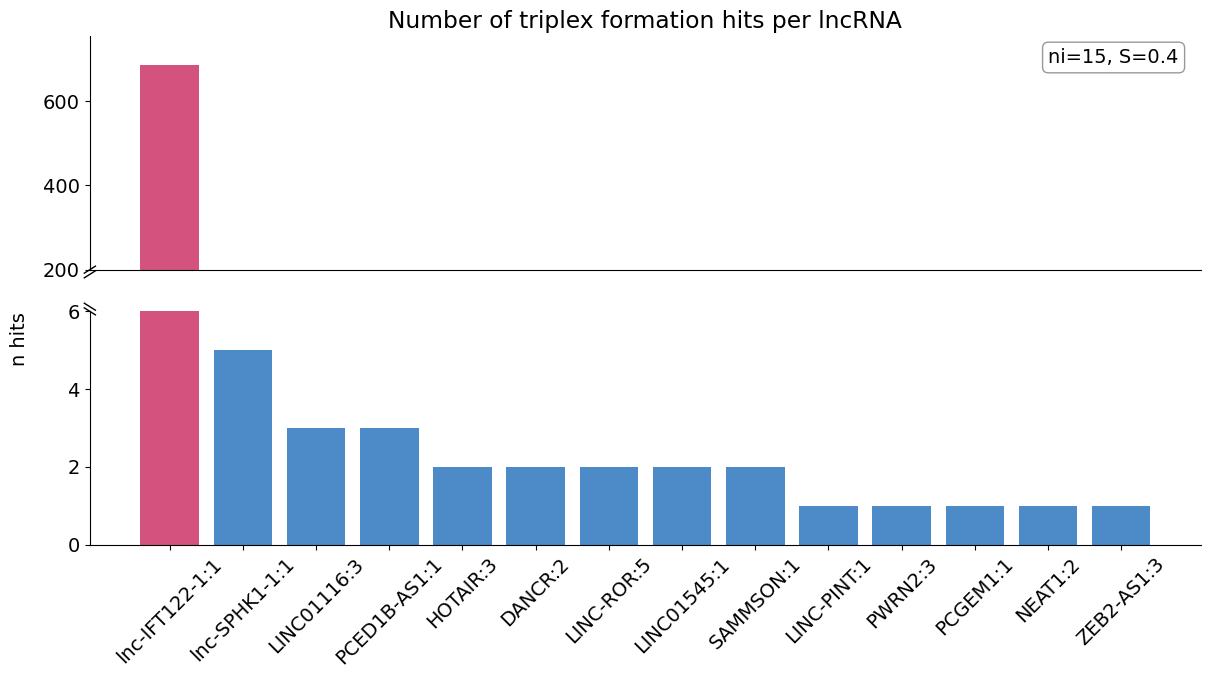

In [17]:
plt.rcParams["font.size"] = 14
plt.rcParams["figure.autolayout"] = True

hits = result[result["delta_n_triplexes"] > -3]
counts = hits.groupby("lnc_id").size().sort_values(ascending=False).reset_index(name="n_hits")

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

sns.barplot(data=counts, x="lnc_id", y="n_hits", ax=ax_top, color="#378ADD")
sns.barplot(data=counts, x="lnc_id", y="n_hits", ax=ax_bot, color="#378ADD")

ift_idx = counts[counts["lnc_id"] == "lnc-IFT122-1:1"].index[0]
ax_top.patches[ift_idx].set_facecolor("#D4537E")
ax_bot.patches[ift_idx].set_facecolor("#D4537E")

ax_top.set_ylim(200, counts["n_hits"].max() * 1.1)
ax_bot.set_ylim(0, 6)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)

kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot([-0.005, 0.005], [-0.015, 0.015], **kwargs)
ax_top.plot([-0.005, 0.005], [-0.035, -0.005], **kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot([-0.005, 0.005], [1.015, 0.985], **kwargs)
ax_bot.plot([-0.005, 0.005], [1.035, 1.005], **kwargs)

ax_bot.set_xlabel("")
ax_bot.tick_params(axis="x", rotation=45)
ax_top.set_ylabel("")
ax_bot.set_ylabel("")
fig.text(-0.01, 0.5, "n hits", va="center", rotation="vertical", fontsize=14)
ax_top.set_title("Number of triplex formation hits per lncRNA")
ax_top.text(0.98, 0.95, "ni=15, S=0.4", transform=ax_top.transAxes,
            fontsize=14, ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="grey", alpha=0.8))

sns.despine(ax=ax_top)
sns.despine(ax=ax_bot)
plt.subplots_adjust(hspace=0.05)
plt.show()

# Analysis for non HULC lncRNA

In [18]:
most = result[result["lnc_id"] != "lnc-IFT122-1:1"]
most

,lnc_id,gene,sample_id,cancer_type,cancer_type_detailed,oncotree_code,variant_class,variant_type,chromosome,mut_start,mut_end,window_start,window_end,strand,healthy_n_triplexes,healthy_mean_identity,healthy_mean_stability,healthy_mean_score,healthy_min_nt,healthy_max_nt,mutated_n_triplexes,mutated_mean_identity,mutated_mean_stability,mutated_mean_score,mutated_min_nt,mutated_max_nt,delta_n_triplexes,delta_mean_score,source_file,ni,S
3071426,DANCR:2,CTNNB1,P-0056450-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Splice_Site,DEL,NC_000003.11,41266072,41266253,41266062,41266262,+,0,0.0,0.0,0.0,0,0,1,61.2903,0.8065,2.7742,31,31,1,2.7742,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
3318287,DANCR:2,ELF3,P-0044320-T01-IM6,Bladder Cancer,Bladder Urothelial Carcinoma,BLCA,Splice_Site,DEL,NC_000001.10,201981382,201981563,201981372,201981572,+,0,0.0,0.0,0.0,0,0,1,72.0000,1.3200,3.2800,25,25,1,3.2800,msk_impact_50k_2026_DANCR_mf100_ni15_S0point4.csv,15,0.4
5803365,HOTAIR:3,BCOR,P-0019731-T01-IM6,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000023.10,39923760,39923938,39923749,39923949,-,0,0.0,0.0,0.0,0,0,1,65.6250,1.6562,2.9375,32,32,1,2.9375,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
6226376,HOTAIR:3,BBC3,P-0008023-T01-IM5,Breast Cancer,Breast Invasive Ductal Carcinoma,IDC,Splice_Site,DEL,NC_000019.9,47729983,47730152,47729967,47730167,-,0,0.0,0.0,0.0,0,0,1,65.9091,1.6841,2.9091,44,44,1,2.9091,msk_impact_50k_2026_HOTAIR_mf100_ni15_S0point4...,15,0.4
8687727,LINC01116:3,PBRM1,P-0012460-T01-IM5,Glioma,Anaplastic Oligodendroglioma,AODG,Splice_Site,DEL,NC_000003.11,52668828,52669011,52668819,52669019,-,0,0.0,0.0,0.0,0,0,1,69.5652,2.5348,3.0870,23,23,1,3.0870,msk_impact_50k_2026_LINC01116_mf100_ni15_S0poi...,15,0.4
8820578,LINC01116:3,CTNNB1,P-0056450-T01-IM6,Colorectal Cancer,Colon Adenocarcinoma,COAD,Splice_Site,DEL,NC_000003.11,41266072,41266253,41266062,41266262,+,0,0.0,0.0,0.0,0,0,1,72.0000,0.6400,3.2800,25,25,1,3.2800,msk_impact_50k_2026_LINC01116_mf100_ni15_S0poi...,15,0.4
9067439,LINC01116:3,ELF3,P-0044320-T01-IM6,Bladder Cancer,Bladder Urothelial Carcinoma,BLCA,Splice_Site,DEL,NC_000001.10,201981382,201981563,201981372,201981572,+,0,0.0,0.0,0.0,0,0,1,67.8571,1.1786,3.0000,28,28,1,3.0000,msk_impact_50k_2026_LINC01116_mf100_ni15_S0poi...,15,0.4
9166823,LINC01545:1,PBRM1,P-0012460-T01-IM5,Glioma,Anaplastic Oligodendroglioma,AODG,Splice_Site,DEL,NC_000003.11,52668828,52669011,52668819,52669019,-,0,0.0,0.0,0.0,0,0,1,69.5652,1.5391,3.0870,23,23,1,3.0870,msk_impact_50k_2026_LINC01545_mf100_ni15_S0poi...,15,0.4
9221184,LINC01545:1,ARID1A,P-0013165-T01-IM5,Endometrial Cancer,Endometrial Carcinoma,UCEC,Frame_Shift_Del,DEL,NC_000001.10,27089520,27089709,27089514,27089714,+,0,0.0,0.0,0.0,0,0,1,64.7059,2.2824,2.9412,17,17,1,2.9412,msk_impact_50k_2026_LINC01545_mf100_ni15_S0poi...,15,0.4
9985399,LINC-PINT:1,SESN2,P-0013435-T02-IM6,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,LUAD,Translation_Start_Site,DEL,NC_000001.10,28586215,28586388,28586201,28586401,+,0,0.0,0.0,0.0,0,0,1,68.4211,1.0526,3.0000,38,38,1,3.0000,msk_impact_50k_2026_LINC_PINT_mf100_ni15_S0poi...,15,0.4


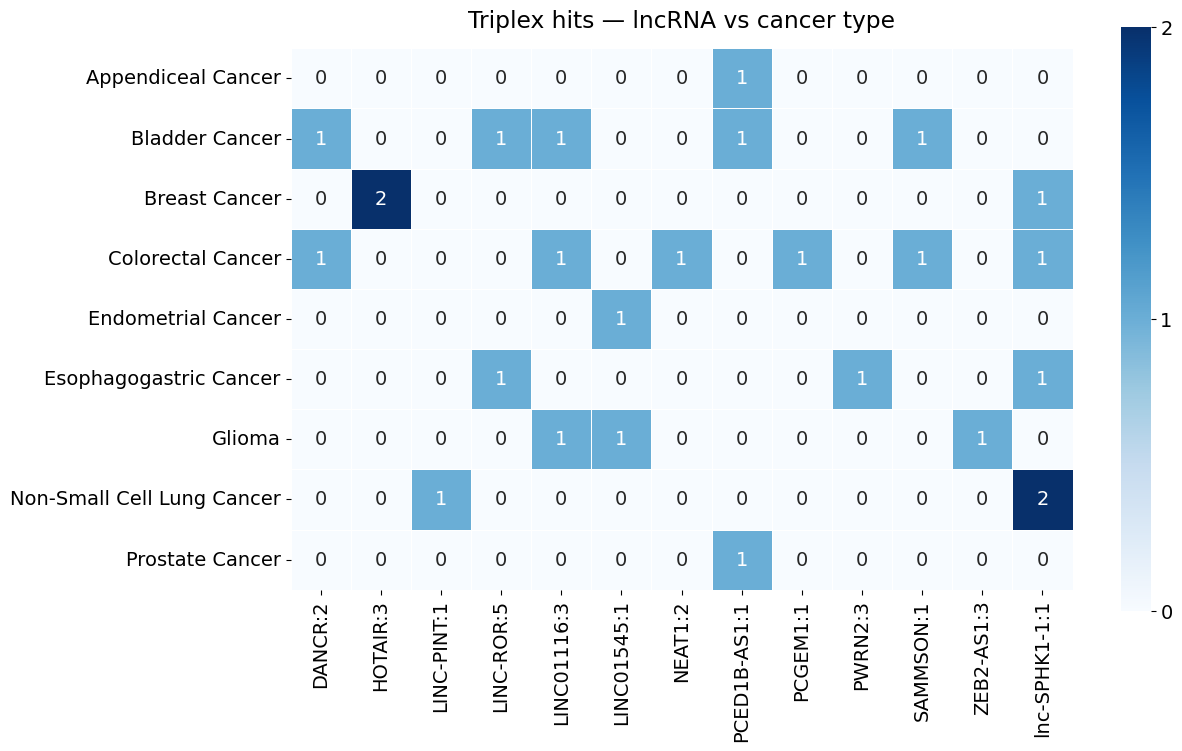

In [39]:
pivot = (most[most["delta_n_triplexes"] > 0]
         .groupby(["cancer_type", "lnc_id"])
         .size()
         .unstack(fill_value=0))

plt.figure(figsize=(13, 15))
sns.heatmap(pivot, cmap="Blues", 
            linewidths=0.5, 
            annot=True, 
            fmt="d", 
            square=True, 
            cbar_kws={"shrink": 0.4, "ticks": range(int(pivot.max().max()) + 1)})
plt.title("Triplex hits — lncRNA vs cancer type", pad=15)
plt.xlabel("")
plt.ylabel("")
plt.show()

In [40]:
most["variant_class"].unique()

array(['Splice_Site', 'Frame_Shift_Del', 'Translation_Start_Site',
       'In_Frame_Del'], dtype=object)

In [41]:
print(most[most["delta_n_triplexes"] > 0]
      .groupby(["lnc_id", "cancer_type", "variant_class"])
      .size()
      .unstack(fill_value=0))

variant_class                             Frame_Shift_Del  In_Frame_Del  \
lnc_id        cancer_type                                                 
DANCR:2       Bladder Cancer                            0             0   
              Colorectal Cancer                         0             0   
HOTAIR:3      Breast Cancer                             0             0   
LINC-PINT:1   Non-Small Cell Lung Cancer                0             0   
LINC-ROR:5    Bladder Cancer                            0             0   
              Esophagogastric Cancer                    0             0   
LINC01116:3   Bladder Cancer                            0             0   
              Colorectal Cancer                         0             0   
              Glioma                                    0             0   
LINC01545:1   Endometrial Cancer                        1             0   
              Glioma                                    0             0   
NEAT1:2       Colorectal 

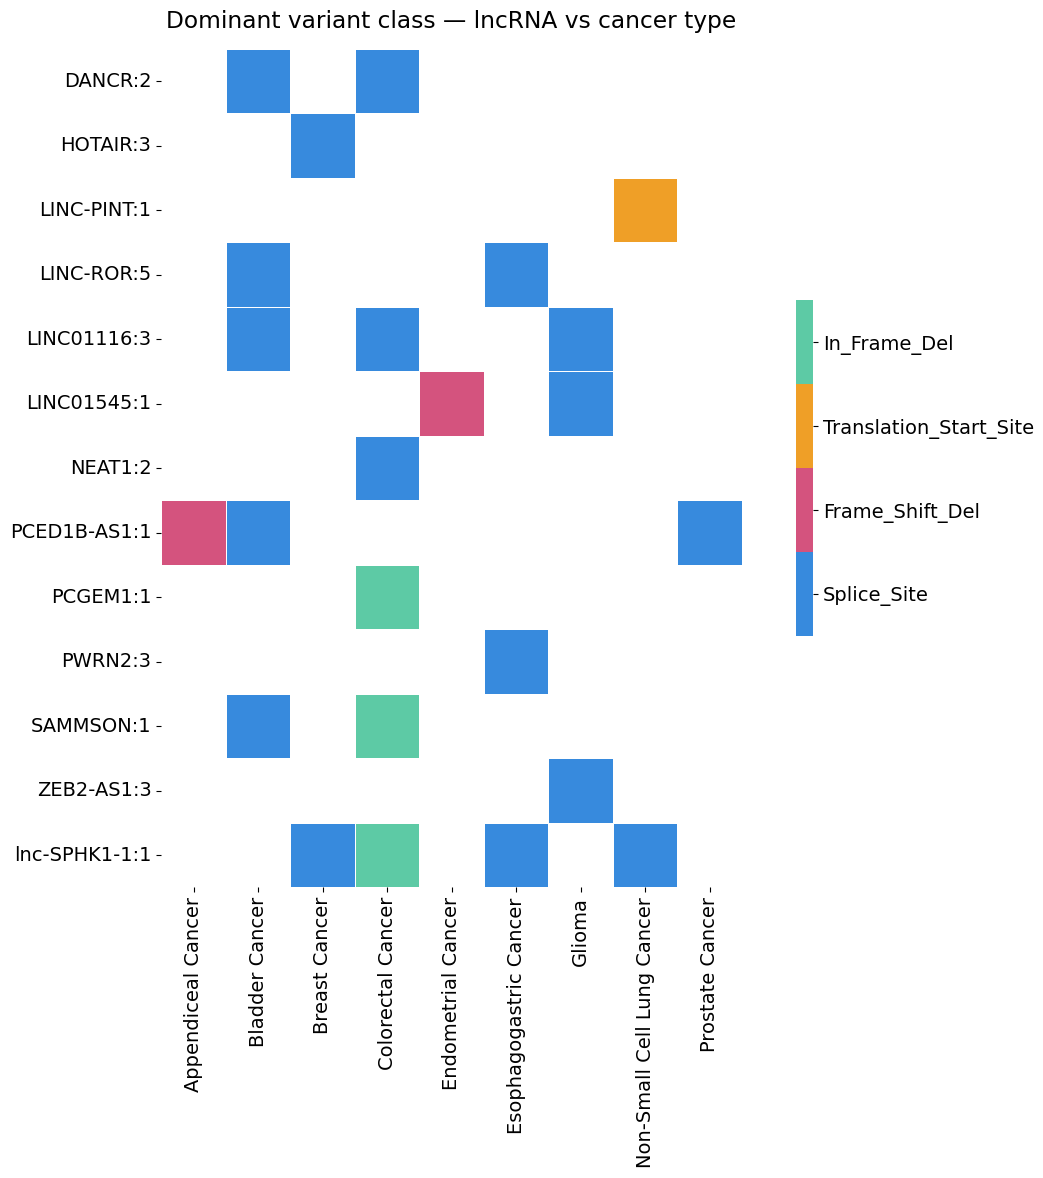

In [44]:
hits = most[most["delta_n_triplexes"] > 0]

# get dominant variant_class per cell
dominant = (hits.groupby(["lnc_id", "cancer_type", "variant_class"])
                .size()
                .reset_index(name="n")
                .sort_values("n", ascending=False)
                .drop_duplicates(subset=["lnc_id", "cancer_type"])
                .pivot(index="lnc_id", columns="cancer_type", values="variant_class"))

# map categories to numbers for heatmap
classes = hits["variant_class"].unique()
class_to_num = {c: i for i, c in enumerate(classes)}
num_to_class = {i: c for c, i in class_to_num.items()}
numeric = dominant.apply(lambda col: col.map(class_to_num))

palette = ["#378ADD", "#D4537E", "#EF9F27", "#5DCAA5", "#888780"]
cmap = plt.matplotlib.colors.ListedColormap(palette[:len(classes)])

plt.figure(figsize=(12, 12))
ax = sns.heatmap(numeric, 
                 cmap=cmap, 
                 linewidths=0.5,
                 vmin=-0.5, 
                 vmax=len(classes) - 0.5,
                 square = True,
                 cbar_kws={"shrink": 0.4, "ticks": list(range(len(classes)))})

ax.collections[0].colorbar.set_ticklabels([num_to_class[i] for i in range(len(classes))])
plt.title("Dominant variant class — lncRNA vs cancer type", pad=15)
plt.xlabel("")
plt.ylabel("")
plt.show()

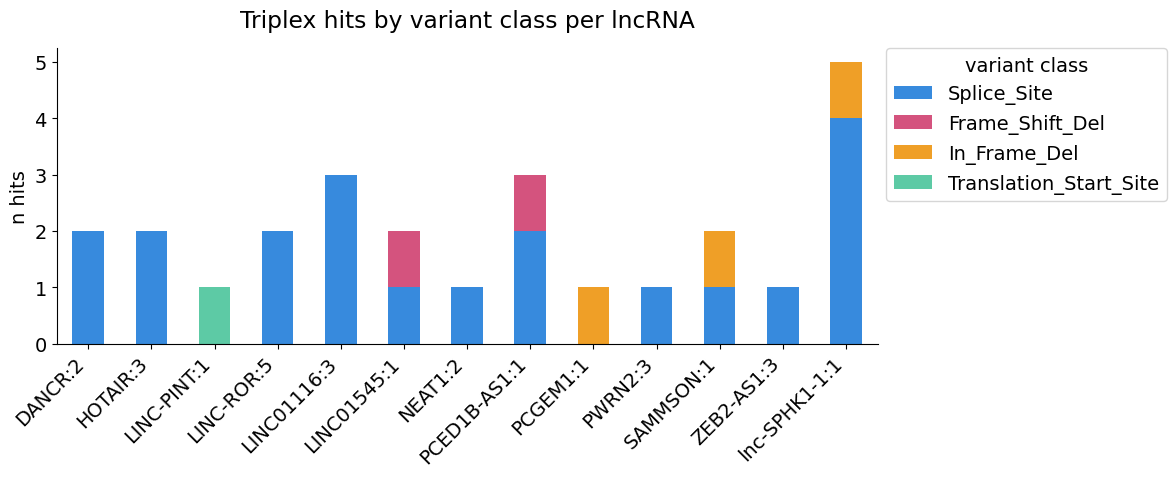

In [49]:
plt.rcParams["font.size"] = 14
plt.rcParams["figure.autolayout"] = True

hits = most[most["delta_n_triplexes"] > 0]

counts = (hits.groupby(["lnc_id", "variant_class"])
              .size()
              .unstack(fill_value=0))

palette = ["#378ADD", "#D4537E", "#EF9F27", "#5DCAA5", "#888780"]

counts = counts[["Splice_Site"] + [c for c in counts.columns if c != "Splice_Site"]]
counts.plot(kind="bar", stacked=True, figsize=(12, 5),
            color=palette[:len(counts.columns)])

plt.title("Triplex hits by variant class per lncRNA", pad=15)
plt.xlabel("")
plt.ylabel("n hits")
plt.legend(title="variant class", bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.xticks(rotation=45, ha="right")
sns.despine()
plt.show()

In [50]:
table = (most[most["delta_n_triplexes"] > 0]
         .groupby("lnc_id")["gene"]
         .apply(lambda x: ", ".join(sorted(x.unique())))
         .reset_index()
         .rename(columns={"gene": "genes"}))

print(table.to_string(index=False))

       lnc_id                         genes
      DANCR:2                  CTNNB1, ELF3
     HOTAIR:3                    BBC3, BCOR
  LINC-PINT:1                         SESN2
   LINC-ROR:5                 KMT2C, PIK3R2
  LINC01116:3           CTNNB1, ELF3, PBRM1
  LINC01545:1                 ARID1A, PBRM1
      NEAT1:2                          TP53
 PCED1B-AS1:1           CDKN1B, ELF3, KMT2D
     PCGEM1:1                          SPEN
      PWRN2:3                       ANKRD11
    SAMMSON:1                 CTNNB1, KMT2C
   ZEB2-AS1:3                         PBRM1
lnc-SPHK1-1:1 ANKRD11, CBL, NF1, PMS2, SPEN


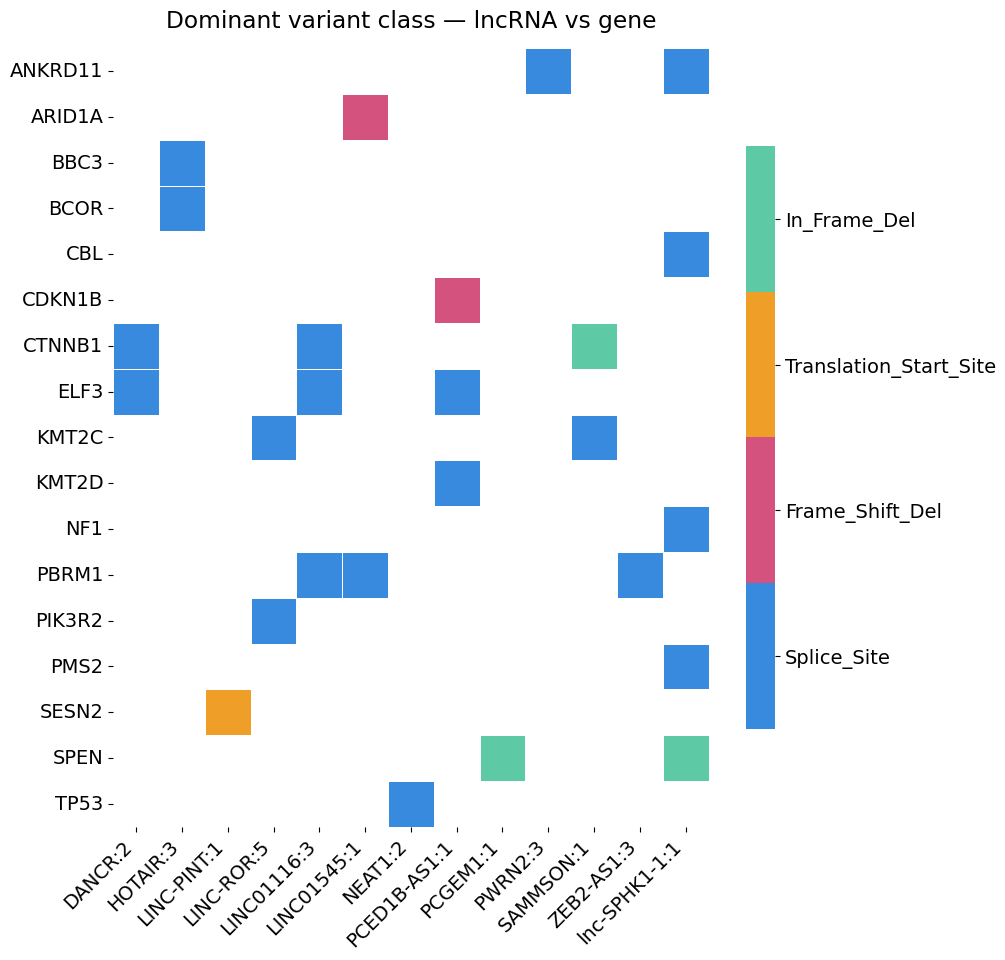

In [62]:
plt.rcParams["font.size"] = 14
plt.rcParams["figure.autolayout"] = True

hits = most[most["delta_n_triplexes"] > 0]

dominant = (hits.groupby(["lnc_id", "gene", "variant_class"])
                .size()
                .reset_index(name="n")
                .sort_values("n", ascending=False)
                .drop_duplicates(subset=["gene", "lnc_id"])
                .pivot(index="gene", columns="lnc_id", values="variant_class"))

classes = hits["variant_class"].unique()
class_to_num = {c: i for i, c in enumerate(classes)}
num_to_class = {i: c for c, i in class_to_num.items()}
numeric = dominant.apply(lambda col: col.map(class_to_num))

palette = ["#378ADD", "#D4537E", "#EF9F27", "#5DCAA5", "#888780"]
cmap = plt.matplotlib.colors.ListedColormap(palette[:len(classes)])

plt.figure(figsize=(10, 15))
ax = sns.heatmap(numeric, cmap=cmap, linewidths=0.5,
                 vmin=-0.5, vmax=len(classes) - 0.5,
                 square = True,
                 cbar_kws={"shrink": 0.4, "ticks": list(range(len(classes)))})

ax.collections[0].colorbar.set_ticklabels([num_to_class[i] for i in range(len(classes))])
plt.title("Dominant variant class — lncRNA vs gene", pad=15)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.show()

# HULC

In [19]:
hulc = result[result["lnc_id"] == "lnc-IFT122-1:1"]